# Retail Sales Forecasting - Training Pipeline
## He thong du doan nhu cau ban hang theo thoi gian thuc tren Azure

**Thu muc**: `ml/`  
**Du lieu**: Dataset that (Rossmann 1M+ giao dich, 1115 cua hang) + Store metadata  
**Mo hinh**: LightGBM, XGBoost, Random Forest, Gradient Boosting  
**Dau ra**: `model_output/model.pkl` -> Deploy len Azure ML Endpoint -> Du doan realtime

### Cau truc thu muc ml/
```
ml/
├── data/                    # Rossmann data (train.csv, test.csv, store.csv)
├── model_output/            # model.pkl, charts/, evaluation_charts/, metadata
├── train.ipynb              # NOTEBOOK CHINH - train + 5 bieu do
├── train_model.py           # Train GBR tren simulated data
├── compare_models.py        # So sanh 9 models tren simulated
├── evaluate_pipelines.py    # So sanh 10 models x 2 pipelines
├── score.py                 # Azure ML Endpoint scoring (simulated)
├── score_rossmann.py        # Batch scoring (Rossmann)
├── deploy_model.py          # Deploy len Azure ML Online Endpoint
├── realtime_forecast.py     # Du doan realtime 24h x 5 regions
└── conda_env.yml            # Environment cho deployment
```

### Pipeline
```
Real Data (data/train.csv + store.csv)
      |
Feature Engineering (lag, time, promo, competition)
      |
Train & Compare Models (LightGBM, XGBoost, RF, GBR)
      |
Visualization Charts (5 bieu do phan tich)
      |
Export model.pkl -> Azure ML Endpoint -> Power BI
```

In [ ]:
# Cell 2: Import thu vien
import os
import sys
import pickle
import warnings
import time
import json
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 10

# Duong dan du lieu — notebook nam trong ml/
BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "model_output")
CHARTS_DIR = os.path.join(OUTPUT_DIR, "charts")
os.makedirs(CHARTS_DIR, exist_ok=True)

print(f"Base dir: {BASE_DIR}")
print(f"Data dir: {DATA_DIR}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Charts dir: {CHARTS_DIR}")

Base dir: c:\Users\Admin\azure-realtime-sales-analytics\ml
Data dir: c:\Users\Admin\azure-realtime-sales-analytics\ml\data
Output dir: c:\Users\Admin\azure-realtime-sales-analytics\ml\model_output
Charts dir: c:\Users\Admin\azure-realtime-sales-analytics\ml\model_output\charts


In [3]:
# Cell 3: Load du lieu THAT
train = pd.read_csv(
    os.path.join(DATA_DIR, "train.csv"),
    parse_dates=['Date'],
    dtype={'StateHoliday': str, 'SchoolHoliday': str},
    low_memory=False
)
test = pd.read_csv(
    os.path.join(DATA_DIR, "test.csv"),
    parse_dates=['Date'],
    dtype={'StateHoliday': str, 'SchoolHoliday': str},
    low_memory=False
)
store = pd.read_csv(os.path.join(DATA_DIR, "store.csv"))

print(f"Train: {train.shape} -- {train['Date'].min().date()} -> {train['Date'].max().date()}")
print(f"Test:  {test.shape}")
print(f"Store: {store.shape} ({store['Store'].nunique()} stores)")
print(f"Sales range: {train['Sales'].min()} -> {train['Sales'].max()}")
print(f"Open=0 rows (se loai): {(train['Open']==0).sum():,}")

Train: (1017209, 9) -- 2013-01-01 -> 2015-07-31
Test:  (41088, 8)
Store: (1115, 10) (1115 stores)
Sales range: 0 -> 41551
Open=0 rows (se loai): 172,817


In [4]:
# Cell 4: Merge store info + Fill missing
train = train.merge(store, how='left', on='Store')
test = test.merge(store, how='left', on='Store')

for df in [train, test]:
    df['CompetitionDistance'] = df['CompetitionDistance'].fillna(1e5)
    df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(1)
    df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(df['Date'].dt.year)
    df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
    df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
    df['PromoInterval'] = df['PromoInterval'].fillna('')

    # IsPromoMonth
    month_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
                 'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
    promo_months_list = df['PromoInterval'].str.split(',').apply(
        lambda x: [month_map[m] for m in x if m in month_map] if isinstance(x, list) else []
    )
    df['IsPromoMonth'] = [d.month in p for d, p in zip(df['Date'], promo_months_list)]
    df['IsPromoMonth'] = df['IsPromoMonth'].astype(int)

print(f"Merged train: {train.shape}, test: {test.shape}")

Merged train: (1017209, 19), test: (41088, 18)


In [5]:
# Cell 5: Feature Engineering -- thoi gian + competition + lag
for df in [train, test]:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
    # Competition open duration
    df['CompetitionOpenMonths'] = (
        (df['Year'] - df['CompetitionOpenSinceYear']) * 12 +
        (df['Month'] - df['CompetitionOpenSinceMonth'])
    ).clip(lower=0)

# Loc cua hang dang mo + co doanh thu
train = train[(train['Open'] == 1) & (train['Sales'] > 0)].copy()
print(f"After filtering Open=1 & Sales>0: {train.shape}")

# Tao lag features (dua tren lich su ban hang that)
train = train.sort_values(['Store', 'Date'])
for lag in [1, 3, 7]:
    train[f'Sales_lag_{lag}'] = train.groupby('Store')['Sales'].shift(lag)
train.fillna(0, inplace=True)

print(f"Lag features created: Sales_lag_1, Sales_lag_3, Sales_lag_7")
print(f"Final train shape: {train.shape}")

After filtering Open=1 & Sales>0: (844338, 25)
Lag features created: Sales_lag_1, Sales_lag_3, Sales_lag_7
Final train shape: (844338, 28)


In [6]:
# Cell 6: Chon features va split du lieu theo thoi gian
features = [
    'Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'IsWeekend',
    'StoreType', 'Assortment',
    'CompetitionDistance', 'CompetitionOpenMonths',
    'Promo2', 'IsPromoMonth',
    'Year', 'Month', 'Day', 'WeekOfYear',
    'Sales_lag_1', 'Sales_lag_3', 'Sales_lag_7',
]
target = 'Sales'

# Encode categorical -> numeric
for col in ['StateHoliday', 'StoreType', 'Assortment', 'SchoolHoliday']:
    if col in train.columns:
        train[col] = train[col].astype('category').cat.codes

X = train[features].copy()
y = train[target].copy()

# Time-based split: train < 2015, validation >= 2015 (chuan cho time-series)
train_mask = train['Date'] < '2015-01-01'
X_train, X_val = X[train_mask], X[~train_mask]
y_train, y_val = y[train_mask], y[~train_mask]

# Subsample training data de tang toc (giu toan bo validation de danh gia chinh xac)
MAX_TRAIN = 100000
if len(X_train) > MAX_TRAIN:
    idx = np.random.RandomState(42).choice(len(X_train), MAX_TRAIN, replace=False)
    X_train = X_train.iloc[idx].reset_index(drop=True)
    y_train = y_train.iloc[idx].reset_index(drop=True)
    print(f"[INFO] Subsample training: {MAX_TRAIN:,} / {train_mask.sum():,} samples")

print(f"Features: {len(features)}")
print(f"Train set: {X_train.shape} ({len(X_train):,} samples)")
print(f"Val set:   {X_val.shape} ({len(X_val):,} samples, >= 2015)")
print(f"Target: {target} -- mean={y.mean():.0f}, std={y.std():.0f}")

[INFO] Subsample training: 100,000 / 648,309 samples
Features: 18
Train set: (100000, 18) (100,000 samples)
Val set:   (196029, 18) (196,029 samples, >= 2015)
Target: Sales -- mean=6956, std=3104


In [7]:
# Cell 7: HUAN LUYEN VA SO SANH 4 MO HINH (toi uu toc do)
models = {
    "LightGBM": LGBMRegressor(
        n_estimators=200, learning_rate=0.05, num_leaves=31,
        max_depth=8, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0, n_jobs=-1
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, max_depth=10, min_samples_leaf=10,
        random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        subsample=0.8, random_state=42
    ),
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_val)
    pred_time = time.time() - t0

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    # MAPE: tranh chia 0
    mask_nonzero = y_val > 0
    mape = np.mean(np.abs((y_val[mask_nonzero] - y_pred[mask_nonzero]) / y_val[mask_nonzero])) * 100

    # Train metrics de kiem tra overfitting
    y_train_pred = model.predict(X_train)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    results.append({
        "Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape,
        "Train_MAE": train_mae, "Train_R2": train_r2,
        "Train_Time": train_time, "Predict_Time": pred_time,
    })
    trained_models[name] = {"model": model, "y_pred": y_pred}

    overfit_gap = (1 - train_mae / mae) * 100
    print(f"   MAE={mae:.2f} | RMSE={rmse:.2f} | R2={r2:.4f} | MAPE={mape:.2f}% | Train={train_time:.1f}s")
    print(f"   Train MAE={train_mae:.2f} | Train R2={train_r2:.4f} | Overfit gap={overfit_gap:.1f}%")

results_df = pd.DataFrame(results).sort_values("MAE")
print("\n" + "="*70)
print("BANG SO SANH CAC MO HINH:")
print("="*70)
print(results_df[["Model", "MAE", "RMSE", "R2", "MAPE", "Train_MAE", "Train_R2", "Train_Time"]].to_string(index=False))


Training LightGBM...
   MAE=799.73 | RMSE=1144.96 | R2=0.8576 | MAPE=12.39% | Train=1.4s
   Train MAE=724.97 | Train R2=0.8885 | Overfit gap=9.3%

Training XGBoost...
   MAE=794.45 | RMSE=1141.21 | R2=0.8585 | MAPE=12.27% | Train=2.2s
   Train MAE=699.82 | Train R2=0.8976 | Overfit gap=11.9%

Training Random Forest...
   MAE=843.50 | RMSE=1220.88 | R2=0.8381 | MAPE=13.01% | Train=11.3s
   Train MAE=774.97 | Train R2=0.8712 | Overfit gap=8.1%

Training Gradient Boosting...
   MAE=818.88 | RMSE=1174.43 | R2=0.8502 | MAPE=12.64% | Train=27.4s
   Train MAE=749.43 | Train R2=0.8808 | Overfit gap=8.5%

BANG SO SANH CAC MO HINH:
            Model        MAE        RMSE       R2      MAPE  Train_MAE  Train_R2  Train_Time
          XGBoost 794.447815 1141.211363 0.858530 12.270350 699.819275  0.897613    2.164722
         LightGBM 799.732512 1144.959962 0.857599 12.390153 724.968290  0.888526    1.414447
Gradient Boosting 818.881933 1174.433191 0.850173 12.642918 749.434913  0.880792   27.3541

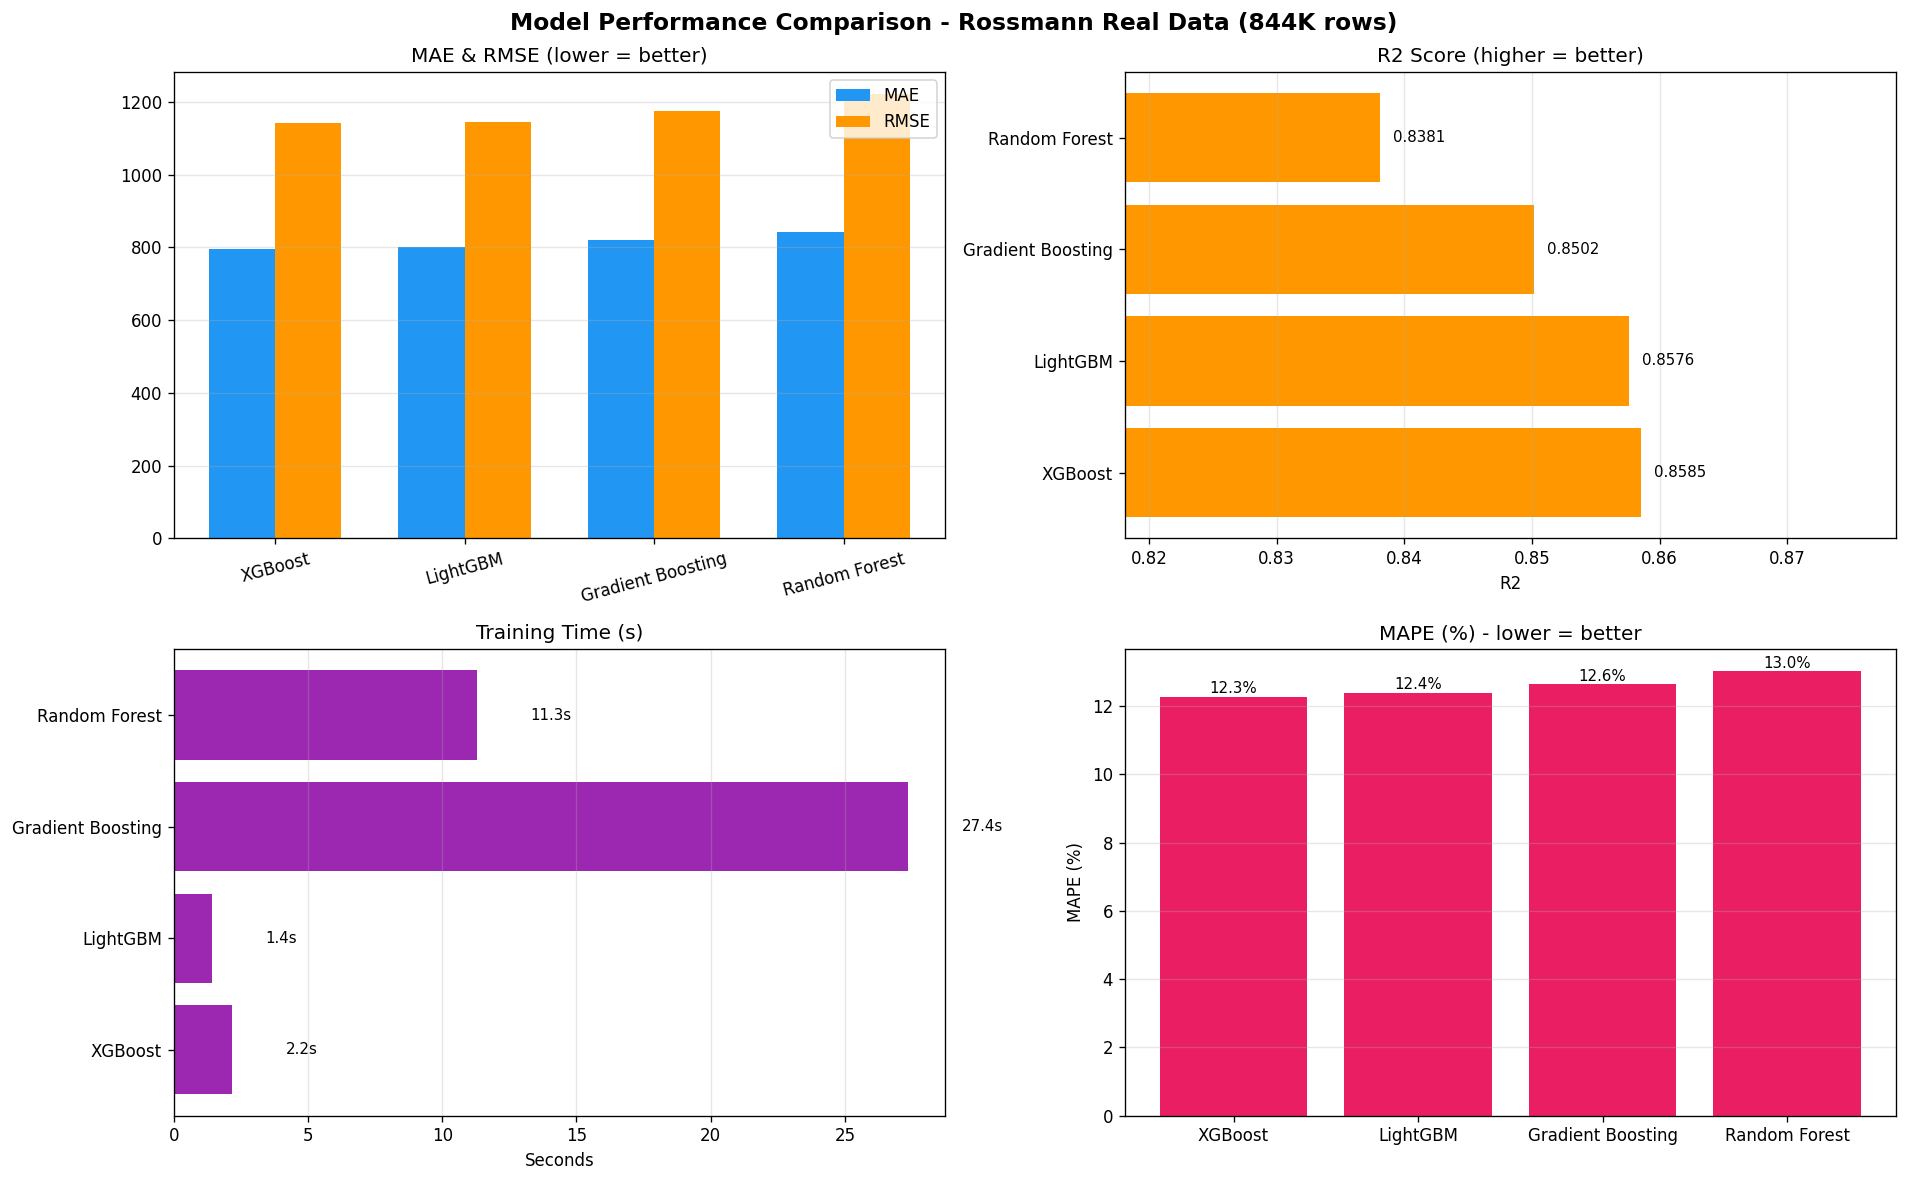

Saved: c:\Users\Admin\azure-realtime-sales-analytics\ml\model_output\charts\01_model_comparison.png


In [8]:
# Cell 8: BIEU DO 1 -- So sanh Metrics cac mo hinh
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Model Performance Comparison - Rossmann Real Data (844K rows)", fontsize=14, fontweight="bold")
model_names = results_df["Model"].tolist()

# MAE + RMSE
ax = axes[0, 0]
x = np.arange(len(model_names))
w = 0.35
ax.bar(x - w/2, results_df["MAE"], w, label="MAE", color="#2196F3")
ax.bar(x + w/2, results_df["RMSE"], w, label="RMSE", color="#FF9800")
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15)
ax.set_title("MAE & RMSE (lower = better)"); ax.legend(); ax.grid(axis="y", alpha=0.3)

# R2 Score
ax = axes[0, 1]
colors = ["#4CAF50" if v > 0.87 else "#FF9800" for v in results_df["R2"]]
bars = ax.barh(model_names, results_df["R2"], color=colors)
ax.set_xlabel("R2"); ax.set_title("R2 Score (higher = better)")
ax.set_xlim(min(results_df["R2"]) - 0.02, max(results_df["R2"]) + 0.02)
for bar, val in zip(bars, results_df["R2"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9)
ax.grid(axis="x", alpha=0.3)

# Training Time
ax = axes[1, 0]
ax.barh(model_names, results_df["Train_Time"], color="#9C27B0")
ax.set_xlabel("Seconds"); ax.set_title("Training Time (s)"); ax.grid(axis="x", alpha=0.3)
for i, v in enumerate(results_df["Train_Time"]):
    ax.text(v + 2, i, f"{v:.1f}s", va="center", fontsize=9)

# MAPE
ax = axes[1, 1]
ax.bar(model_names, results_df["MAPE"], color="#E91E63")
ax.set_ylabel("MAPE (%)"); ax.set_title("MAPE (%) - lower = better"); ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(results_df["MAPE"]):
    ax.text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
path = os.path.join(CHARTS_DIR, "01_model_comparison.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

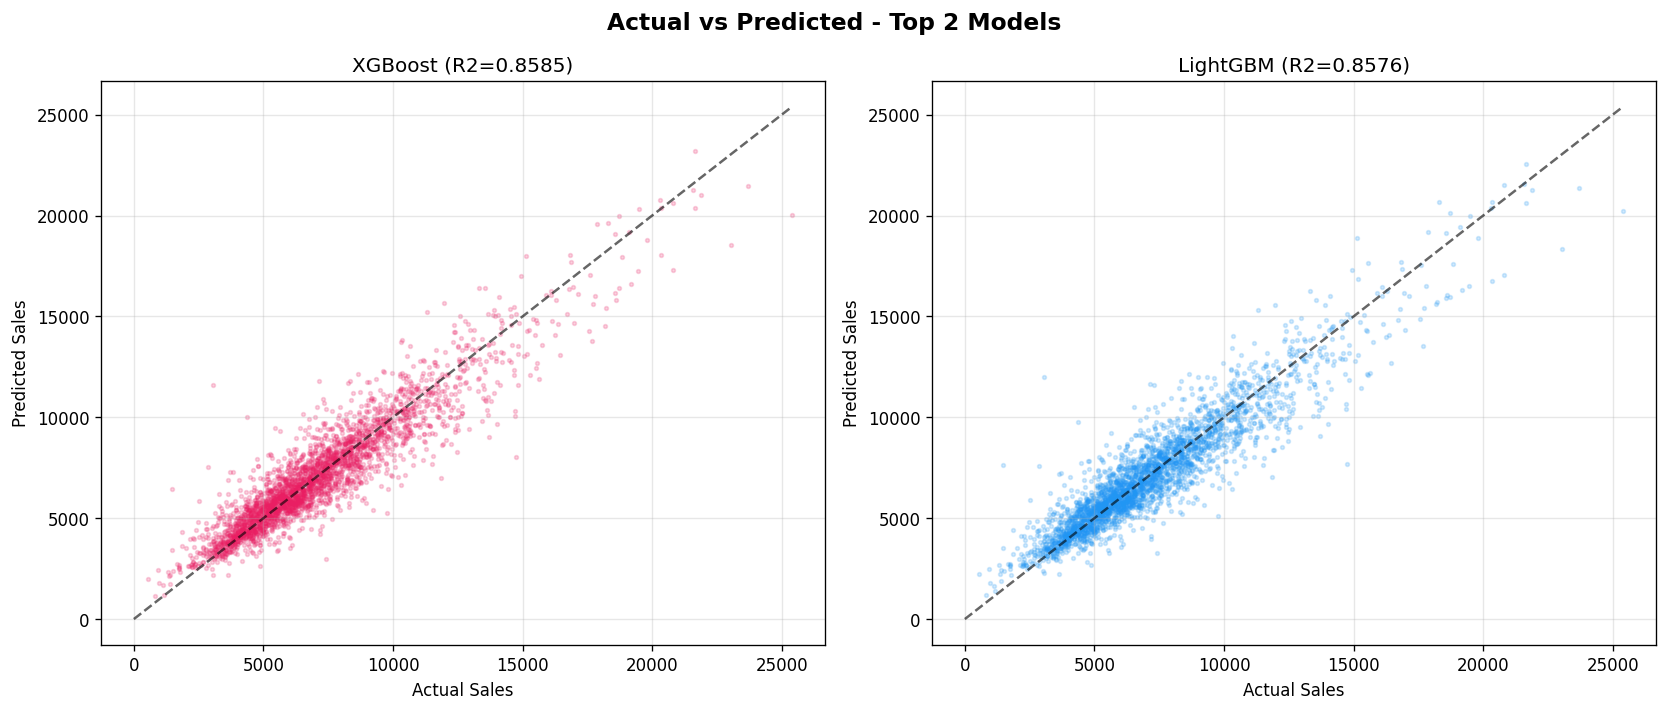

Saved: c:\Users\Admin\azure-realtime-sales-analytics\ml\model_output\charts\02_actual_vs_predicted.png


In [9]:
# Cell 9: BIEU DO 2 -- Actual vs Predicted (Top 2 models)
top2 = results_df.head(2)["Model"].tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Actual vs Predicted - Top 2 Models", fontsize=14, fontweight="bold")

for i, name in enumerate(top2):
    ax = axes[i]
    yp = trained_models[name]["y_pred"]
    rng = np.random.RandomState(42)
    sample_idx = rng.choice(len(y_val), min(3000, len(y_val)), replace=False)
    yt_s = y_val.values[sample_idx]
    yp_s = yp[sample_idx]
    ax.scatter(yt_s, yp_s, alpha=0.2, s=5, color="#E91E63" if i == 0 else "#2196F3")
    lims = [0, max(yt_s.max(), yp_s.max())]
    ax.plot(lims, lims, "k--", alpha=0.6, linewidth=1.5)
    r2 = r2_score(y_val, yp)
    ax.set_xlabel("Actual Sales"); ax.set_ylabel("Predicted Sales")
    ax.set_title(f"{name} (R2={r2:.4f})"); ax.grid(alpha=0.3)

plt.tight_layout()
path = os.path.join(CHARTS_DIR, "02_actual_vs_predicted.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

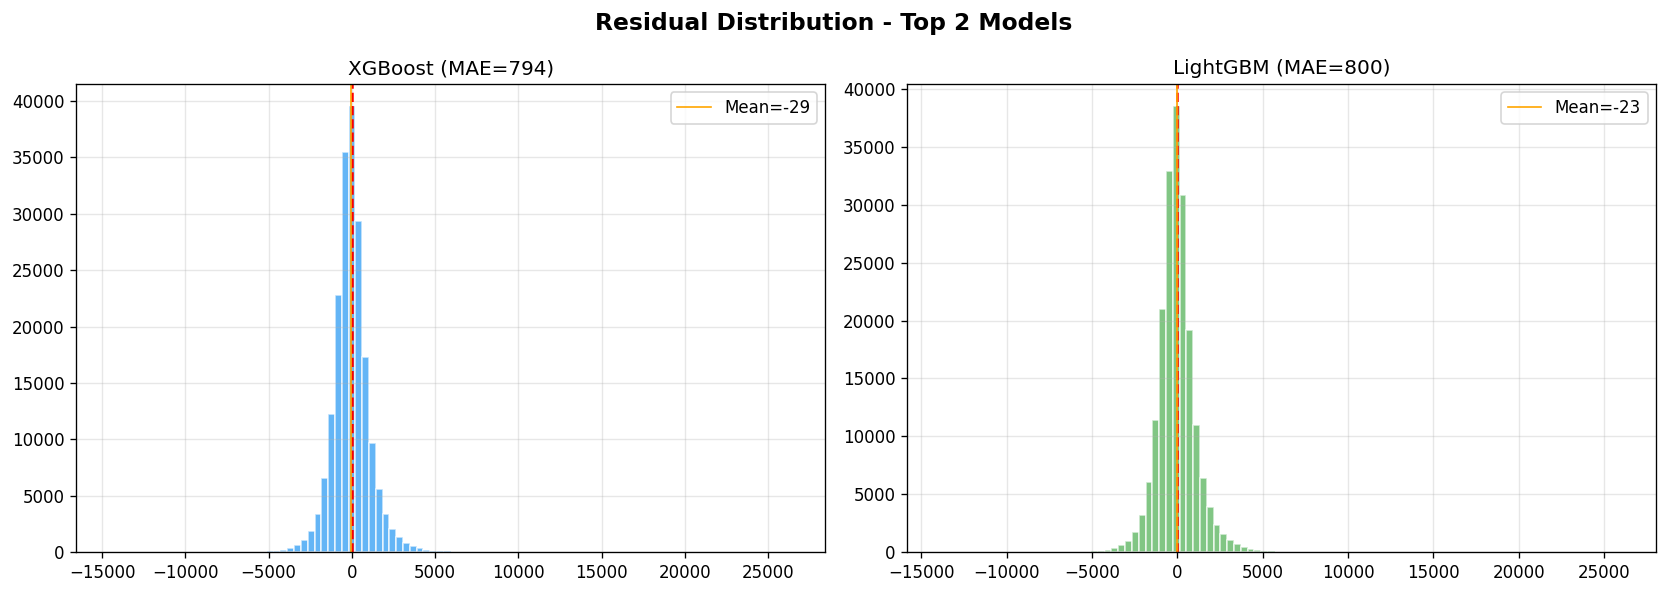

Saved: c:\Users\Admin\azure-realtime-sales-analytics\ml\model_output\charts\03_residual_distribution.png


In [10]:
# Cell 10: BIEU DO 3 -- Residual Distribution (Top 2 models)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Residual Distribution - Top 2 Models", fontsize=14, fontweight="bold")

for i, name in enumerate(top2):
    ax = axes[i]
    yp = trained_models[name]["y_pred"]
    residuals = y_val.values - yp
    ax.hist(residuals, bins=100, color="#2196F3" if i == 0 else "#4CAF50", alpha=0.7, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.axvline(np.mean(residuals), color="orange", linestyle="-", linewidth=1, label=f"Mean={np.mean(residuals):.0f}")
    mae = mean_absolute_error(y_val, yp)
    ax.set_title(f"{name} (MAE={mae:.0f})")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
path = os.path.join(CHARTS_DIR, "03_residual_distribution.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

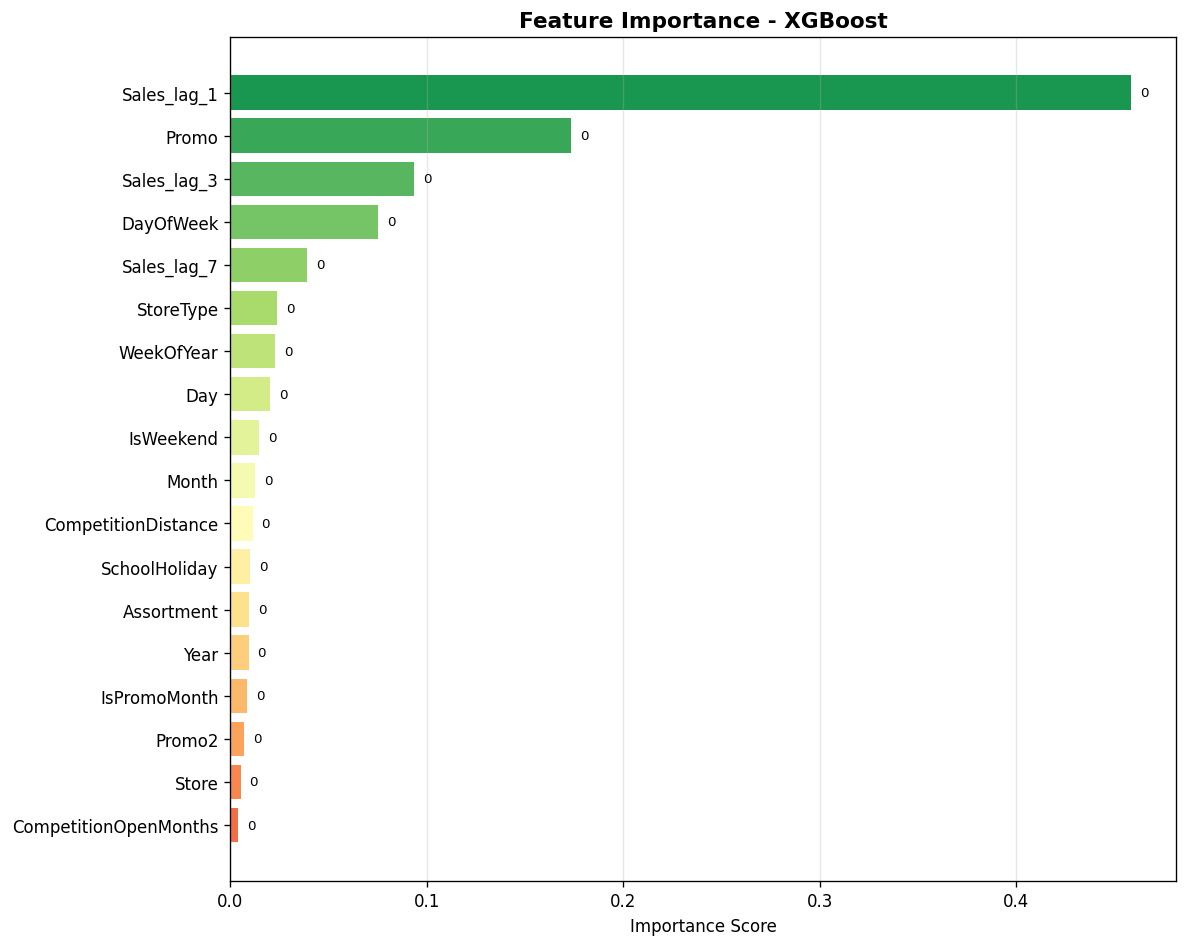

Saved: c:\Users\Admin\azure-realtime-sales-analytics\ml\model_output\charts\04_feature_importance.png

Top 5 features:
   1. Sales_lag_1: 0.4583
   2. Promo: 0.1736
   3. Sales_lag_3: 0.0937
   4. DayOfWeek: 0.0751
   5. Sales_lag_7: 0.0392


In [11]:
# Cell 11: BIEU DO 4 -- Feature Importance (Best model)
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]["model"]

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(features)))
    ax.barh(range(len(features)), importances[indices], color=colors_fi)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels([features[i] for i in indices], fontsize=10)
    ax.set_title(f"Feature Importance - {best_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Importance Score")
    ax.grid(axis="x", alpha=0.3)
    for i, v in enumerate(importances[indices]):
        ax.text(v + max(importances) * 0.01, i, f"{v:.0f}", va="center", fontsize=8)

    plt.tight_layout()
    path = os.path.join(CHARTS_DIR, "04_feature_importance.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")
    print(f"\nTop 5 features:")
    for rank, idx in enumerate(np.argsort(importances)[::-1][:5], 1):
        print(f"   {rank}. {features[idx]}: {importances[idx]:.4f}")

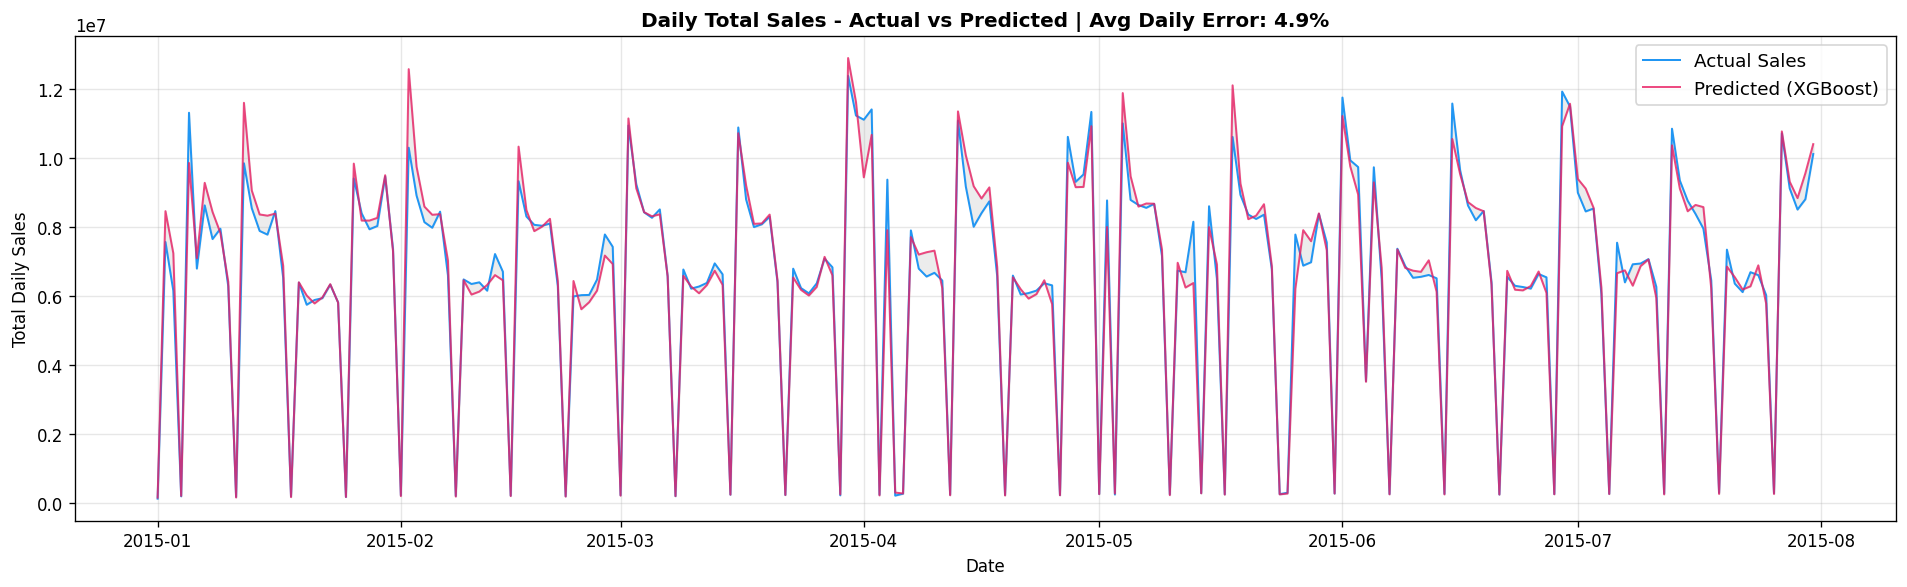

Saved: c:\Users\Admin\azure-realtime-sales-analytics\ml\model_output\charts\05_sales_trend.png


In [12]:
# Cell 12: BIEU DO 5 -- Sales trend: Actual vs Predicted theo thoi gian
best_pred = trained_models[best_name]["y_pred"]
val_dates = train.loc[~train_mask, 'Date'].values

# Aggregate theo ngay de ve trend
val_df = pd.DataFrame({
    'Date': val_dates,
    'Actual': y_val.values,
    'Predicted': best_pred,
})
daily = val_df.groupby('Date').agg({'Actual': 'sum', 'Predicted': 'sum'}).reset_index()
daily = daily.sort_values('Date')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily['Date'], daily['Actual'], label='Actual Sales', color='#2196F3', linewidth=1.2)
ax.plot(daily['Date'], daily['Predicted'], label=f'Predicted ({best_name})', color='#E91E63', linewidth=1.2, alpha=0.8)
ax.fill_between(daily['Date'], daily['Actual'], daily['Predicted'], alpha=0.15, color='gray')
daily_err = np.abs(daily['Actual'] - daily['Predicted']) / daily['Actual'] * 100
ax.set_title(f"Daily Total Sales - Actual vs Predicted | Avg Daily Error: {daily_err.mean():.1f}%", fontweight="bold")
ax.legend(fontsize=11); ax.grid(alpha=0.3)
ax.set_xlabel("Date"); ax.set_ylabel("Total Daily Sales")

plt.tight_layout()
path = os.path.join(CHARTS_DIR, "05_sales_trend.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

In [13]:
# Cell 13: Luu model TOT NHAT + metadata
best_model_obj = trained_models[best_name]["model"]
best_metrics = results_df[results_df["Model"] == best_name].iloc[0]

# Luu model
model_path = os.path.join(OUTPUT_DIR, "model.pkl")
with open(model_path, 'wb') as f:
    pickle.dump(best_model_obj, f)

# Luu metadata cho Azure ML Endpoint
metadata = {
    "model_name": best_name,
    "feature_columns": features,
    "target": target,
    "metrics": {
        "MAE": round(float(best_metrics["MAE"]), 2),
        "RMSE": round(float(best_metrics["RMSE"]), 2),
        "R2": round(float(best_metrics["R2"]), 4),
        "MAPE": round(float(best_metrics["MAPE"]), 2),
    },
    "training_samples": int(X_train.shape[0]),
    "validation_samples": int(X_val.shape[0]),
    "total_stores": int(train['Store'].nunique()),
    "date_range": f"{train['Date'].min().date()} -> {train['Date'].max().date()}",
    "trained_at": datetime.utcnow().isoformat(),
    "model_version": "v2.0",
    "all_models_comparison": results_df[["Model", "MAE", "RMSE", "R2", "MAPE"]].to_dict(orient="records"),
}

metadata_path = os.path.join(OUTPUT_DIR, "model_metadata.json")
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"Best model: {best_name}")
print(f"Saved: {model_path}")
print(f"Saved: {metadata_path}")
print(f"\nMetrics:")
for k, v in metadata["metrics"].items():
    print(f"   {k}: {v}")

Best model: XGBoost
Saved: c:\Users\Admin\azure-realtime-sales-analytics\ml\model_output\model.pkl
Saved: c:\Users\Admin\azure-realtime-sales-analytics\ml\model_output\model_metadata.json

Metrics:
   MAE: 794.45
   RMSE: 1141.21
   R2: 0.8585
   MAPE: 12.27


In [14]:
# Cell 14: Metrics Report + Naive Baseline
best_pred = trained_models[best_name]["y_pred"]

# Naive baseline: Sales_lag_1
naive_pred = X_val['Sales_lag_1'].values
mask_nonzero = y_val > 0

mae = mean_absolute_error(y_val, best_pred)
rmse = np.sqrt(mean_squared_error(y_val, best_pred))
mape = np.mean(np.abs((y_val[mask_nonzero] - best_pred[mask_nonzero]) / y_val[mask_nonzero])) * 100

mae_naive = mean_absolute_error(y_val, naive_pred)
rmse_naive = np.sqrt(mean_squared_error(y_val, naive_pred))
mape_naive = np.mean(np.abs((y_val[mask_nonzero] - naive_pred[mask_nonzero]) / y_val[mask_nonzero])) * 100

report = f"""# Metrics Report -- {best_name}

| Metric | {best_name} | Naive (lag_1) | Improvement |
|--------|-------------|---------------|-------------|
| MAE    | {mae:.2f} | {mae_naive:.2f} | {(1 - mae/mae_naive)*100:.1f}% |
| RMSE   | {rmse:.2f} | {rmse_naive:.2f} | {(1 - rmse/rmse_naive)*100:.1f}% |
| MAPE   | {mape:.2f}% | {mape_naive:.2f}% | {(1 - mape/mape_naive)*100:.1f}% |
| R2     | {r2_score(y_val, best_pred):.4f} | {r2_score(y_val, naive_pred):.4f} | -- |

**Training data**: {X_train.shape[0]:,} samples (< 2015)
**Validation data**: {X_val.shape[0]:,} samples (>= 2015)
**Stores**: {train['Store'].nunique():,}
**Date range**: {train['Date'].min().date()} -> {train['Date'].max().date()}
"""

report_path = os.path.join(OUTPUT_DIR, "metrics_report.md")
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)

print(report)
print(f"Saved: {report_path}")

# Metrics Report -- XGBoost

| Metric | XGBoost | Naive (lag_1) | Improvement |
|--------|-------------|---------------|-------------|
| MAE    | 794.45 | 1359.55 | 41.6% |
| RMSE   | 1141.21 | 2047.50 | 44.3% |
| MAPE   | 12.27% | 20.68% | 40.7% |
| R2     | 0.8585 | 0.5446 | -- |

**Training data**: 100,000 samples (< 2015)
**Validation data**: 196,029 samples (>= 2015)
**Stores**: 1,115
**Date range**: 2013-01-01 -> 2015-07-31

Saved: c:\Users\Admin\azure-realtime-sales-analytics\ml\model_output\metrics_report.md


In [15]:
# Cell 15: Du doan test set
def create_features_test(df_test, store_df):
    """Feature engineering cho test set (giong training)."""
    df = df_test.copy()
    df = df.merge(store_df, how='left', on='Store')
    df['CompetitionDistance'] = df['CompetitionDistance'].fillna(1e5)
    df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(1)
    df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(df['Date'].dt.year)
    df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
    df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
    df['PromoInterval'] = df['PromoInterval'].fillna('')

    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
    df['CompetitionOpenMonths'] = ((df['Year'] - df['CompetitionOpenSinceYear'])*12 +
                                    (df['Month'] - df['CompetitionOpenSinceMonth'])).clip(lower=0)

    month_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
                 'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
    promo_list = df['PromoInterval'].str.split(',').apply(
        lambda x: [month_map[m] for m in x if m in month_map] if isinstance(x, list) else [])
    df['IsPromoMonth'] = [d.month in p for d, p in zip(df['Date'], promo_list)]
    df['IsPromoMonth'] = df['IsPromoMonth'].astype(int)

    # Lag = 0 cho test (khong co lich su ban hang)
    for lag in [1, 3, 7]:
        df[f'Sales_lag_{lag}'] = 0

    # Encode categorical
    for col in ['StateHoliday', 'StoreType', 'Assortment', 'SchoolHoliday']:
        if col in df.columns:
            df[col] = df[col].astype('category').cat.codes
    return df

# Reload test (tranh dung test da bi merge o tren)
test_raw = pd.read_csv(os.path.join(DATA_DIR, "test.csv"), parse_dates=['Date'],
                       dtype={'StateHoliday': str, 'SchoolHoliday': str})
test_prepared = create_features_test(test_raw, store)

# Dam bao dung features
for f in features:
    if f not in test_prepared.columns:
        test_prepared[f] = 0

test_raw['PredictedSales'] = best_model_obj.predict(test_prepared[features])
submission_path = os.path.join(OUTPUT_DIR, "submission.csv")
test_raw[['Id', 'PredictedSales']].to_csv(submission_path, index=False)
print(f"Predictions: {test_raw.shape[0]:,} rows")
print(f"Saved: {submission_path}")
print(f"Predicted Sales range: {test_raw['PredictedSales'].min():.0f} -> {test_raw['PredictedSales'].max():.0f}")

Predictions: 41,088 rows
Saved: c:\Users\Admin\azure-realtime-sales-analytics\ml\model_output\submission.csv
Predicted Sales range: 1372 -> 8176


# Kien truc he thong tong the

Toan bo pipeline da san sang trien khai len Azure theo kien truc sau:

```
+-------------------+       +-------------------+       +----------------------------+
| Python Simulator  | ----> | Azure Event Hubs  | ----> | Azure Functions            |
| (data_generator/) |       | (sales-events)    |       | (Validation Layer)         |
| Sales JSON 1-5s   |       | 3 hubs: sales,    |       | azure_functions/           |
|                   |       | weather, stock    |       | - Schema validation        |
+-------------------+       +-------------------+       | - Data cleaning            |
        ^                                               | - Deduplication            |
        |  CI/CD                                        +----------------------------+
        |                                                       |
+-------------------+                                           v
| GitHub Actions    |                               +----------------------------+
| .github/workflows |                               | Azure Stream Analytics     |
| - deploy-sim      |                               | (stream_analytics/)        |
| - deploy-func     |                               | Tumbling window 1-min      |
| - deploy-ml       |                               | Aggregation + Enrichment   |
| - ci (lint/test)  |                               +----------------------------+
+-------------------+                                    |              |
                                                         v              v
+-------------------+       +-------------------+  +-----------+  +-----------+
| Azure Key Vault   | <---- | Azure SQL Database |  | ML        |  | Power BI  |
| (security/)       |       | (sql/)             |  | Endpoint  |  | Dashboard |
| Managed Identity  |       | SalesRaw           |  | (ml/)     |  | (powerbi/)|
| Secrets rotation  |       | SalesAgg5m         |  | XGBoost   |  | DirectQ   |
+-------------------+       | SalesForecast      |  | LightGBM  |  +-----------+
                            +-------------------+  +-----------+
        ^                        ^       |              ^  |
        |                        |       v              |  v
+-------------------+            |  +-------------------+
| Azure Monitor     |            +--| Predictions       |
| (monitoring/)     |               | SalesForecast tbl |
| App Insights      |               +-------------------+
| Alerts & Metrics  |
+-------------------+
```

## Data Flow
1. **Sim → EH**: Sales JSON events (1-5s/event)
2. **EH → Functions**: Event Hub trigger (stream)
3. **Functions → ASA**: Validated & cleaned events
4. **ASA → SQL**: Aggregated data (1-min tumbling window)
5. **SQL ↔ ML Endpoint**: Feature data → Predictions
6. **SQL → Power BI**: DirectQuery (Actual vs Forecast)
7. **Key Vault → All**: Secrets via Managed Identity
8. **All → Monitor**: Logs, metrics, traces
9. **GitHub Actions → Deploy**: CI/CD for Sim, Functions, ML Endpoint

In [16]:
# Cell 17: Tong ket -- liet ke toan bo file output
print("="*60)
print("TRAINING HOAN TAT -- File output:")
print("="*60)

output_files = []
for root, dirs, files in os.walk(OUTPUT_DIR):
    for f in files:
        fpath = os.path.join(root, f)
        size = os.path.getsize(fpath)
        output_files.append((fpath, size))
        print(f"  {os.path.relpath(fpath, BASE_DIR):50s} ({size:>10,} bytes)")

print(f"\nBest model: {best_name}")
print(f"MAE = {metadata['metrics']['MAE']}")
print(f"RMSE = {metadata['metrics']['RMSE']}")
print(f"R2 = {metadata['metrics']['R2']}")
print(f"MAPE = {metadata['metrics']['MAPE']}%")
print(f"\nTiep theo: Deploy len Azure ML Endpoint")
print(f"   python ml/deploy_model.py --model-dir ./model_output")

TRAINING HOAN TAT -- File output:
  model_output\metrics_report.md                     (       447 bytes)
  model_output\model.pkl                             (   964,729 bytes)
  model_output\model_metadata.json                   (     1,484 bytes)
  model_output\submission.csv                        (   673,561 bytes)
  model_output\charts\01_model_comparison.png        (   137,999 bytes)
  model_output\charts\02_actual_vs_predicted.png     (   226,364 bytes)
  model_output\charts\03_residual_distribution.png   (    66,247 bytes)
  model_output\charts\04_feature_importance.png      (    67,561 bytes)
  model_output\charts\05_sales_trend.png             (   298,386 bytes)

Best model: XGBoost
MAE = 794.45
RMSE = 1141.21
R2 = 0.8585
MAPE = 12.27%

Tiep theo: Deploy len Azure ML Endpoint
   python ml/deploy_model.py --model-dir ./model_output
